In [1]:
import matplotlib
import sys

sys.path.append("/kaggle/input/models/minhkhanhdoan/deepland-mid-224/pytorch/default/1")

In [2]:
import torch
import math
import torch.nn as nn
import torch.nn.functional as F

class Flatten(nn.Module):
    def forward(self, x):
        return x.view(x.size(0), -1)

class ChannelGate(nn.Module):
    def __init__(self, gate_channels, reduction_ratio=16):
        super(ChannelGate, self).__init__()
        # if gate_channels // reduction_ratio == 0: #fixed for mobileNetV2
        #     reduction_ratio = gate_channels
        self.mlp = nn.Sequential(
            Flatten(),
            nn.Linear(gate_channels, gate_channels // reduction_ratio),
            nn.ReLU(),
            nn.Linear(gate_channels // reduction_ratio, gate_channels)
            )
    def forward(self, x):
        squeeze_avg = F.avg_pool2d( x, (x.size(2), x.size(3)), stride=(x.size(2), x.size(3)))
        channel_att = self.mlp(squeeze_avg)
        scale = torch.sigmoid(channel_att).unsqueeze(2).unsqueeze(3).expand_as(x)
        return x * scale

class SE(nn.Module):
    def __init__(self, gate_channels, reduction_ratio=16):
        super(SE, self).__init__()
        self.ChannelGate = ChannelGate(gate_channels, reduction_ratio)
    def forward(self, x):
        x_out = self.ChannelGate(x)
        return x_out

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class PDPBlock(nn.Module):
    def __init__(self, in_channels, out_channels, s, drop_p=0.0):
        super(PDPBlock,self).__init__()
        self.pw1=nn.Conv2d(in_channels=in_channels,out_channels=in_channels,kernel_size=1,bias=False)
        self.dw1=nn.Conv2d(in_channels=in_channels,out_channels=in_channels,kernel_size=3,stride=s,padding=1,groups=in_channels,dilation=1,bias=False)
        self.dw2=nn.Conv2d(in_channels=in_channels,out_channels=in_channels,kernel_size=3,stride=1,padding=2,groups=in_channels,dilation=2,bias=False)
        self.pw2=nn.Conv2d(in_channels=2*in_channels,out_channels=out_channels,kernel_size=1,bias=False)
        self.SE=SE(out_channels,16); self.s=s
        self.PwR=nn.Conv2d(in_channels=in_channels,out_channels=out_channels,kernel_size=1,stride=s,bias=False)

    def forward(self,x):
      Pw1 = self.pw1(x)

      Dw1 = F.relu(self.dw1(Pw1))
      Dw2 = F.relu(self.dw2(Pw1))

      if self.s == 2:
          Dw2 = F.avg_pool2d(Dw2, kernel_size=2, stride=2)

      Dw = torch.cat([Dw1, Dw2], dim=1)
      Dw = self.shuffle(Dw)

      out = self.pw2(Dw)
      out = self.SE(out)

      if self.s == 1 and x.size() == out.size():
          out = x + out
      else:
          out = self.PwR(x) + out

      return F.relu(out)

    def shuffle(self,x):
        b, c, h, w = x.size()
        g = 2

        x = x.view(b, g, c // g, h, w)
        x = x.permute(0, 2, 1, 3, 4).contiguous()

        return x.view(b, c, h, w)

class NetMid(nn.Module):
    def __init__(self, image_size, n_class=10):
        super(NetMid, self).__init__()
        self.image_size = image_size
        small_input = image_size <= 64

        stem_stride = 1 if small_input else 2
        block3_stride = 1 if small_input else 2
        block8_stride = 1 if small_input else 2
        block10_stride = 1 if small_input else 2
 
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, stride=stem_stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(32)
        self.block1 = PDPBlock(in_channels=32, out_channels=64, s=1, drop_p=0.02)
        self.block2 = PDPBlock(in_channels=64, out_channels=64, s=1, drop_p=0.02)
        self.block3 = PDPBlock(in_channels=64, out_channels=128, s=block3_stride, drop_p=0.04)
        self.block5 = PDPBlock(in_channels=128, out_channels=128, s=1, drop_p=0.05)
        self.block6 = PDPBlock(in_channels=128, out_channels=256, s=2, drop_p=0.06)
        self.block7 = PDPBlock(in_channels=256, out_channels=256, s=1, drop_p=0.07)
        self.block8 = PDPBlock(in_channels=256, out_channels=256, s=block8_stride, drop_p=0.08)
        self.block9 = PDPBlock(in_channels=256, out_channels=512, s=1, drop_p=0.10)
        self.block10 = PDPBlock(in_channels=512, out_channels=512, s=block10_stride, drop_p=0.10)
        self.conv2 = nn.Conv2d(in_channels=512, out_channels=1024, kernel_size=1, stride=1, padding=0, bias=False)
        self.bn2 = nn.BatchNorm2d(1024)
        self.avgpool = nn.AdaptiveAvgPool2d(output_size=1)
        self.dropout = nn.Dropout(p=0.35 if small_input else 0.4)
        self.fc1 = nn.Linear(1024, 512)
        self.bn_fc = nn.BatchNorm1d(512)
        self.fc2 = nn.Linear(512, n_class)
        self.act = nn.SiLU(inplace=True)
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.act(self.bn1(self.conv1(x)))
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block5(x)
        x = self.block6(x)
        x = self.block7(x)
        x = self.block8(x)
        x = self.block9(x)
        x = self.block10(x)
        x = self.act(self.bn2(self.conv2(x)))
        x = self.avgpool(x)
        x = x.view(x.size(0), -1)
        x = self.dropout(x)
        x = self.act(self.bn_fc(self.fc1(x)))
        x = self.dropout(x)
        return self.fc2(x)
net = NetMid(image_size =224, n_class=5)
net.to("cuda")
from torchsummary import summary
print(net)
summary(net, (3,32,32), device="cuda")

NetMid(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (block1): PDPBlock(
    (pw1): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (dw1): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
    (dw2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(2, 2), dilation=(2, 2), groups=32, bias=False)
    (pw2): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (SE): SE(
      (ChannelGate): ChannelGate(
        (mlp): Sequential(
          (0): Flatten()
          (1): Linear(in_features=64, out_features=4, bias=True)
          (2): ReLU()
          (3): Linear(in_features=4, out_features=64, bias=True)
        )
      )
    )
    (PwR): Conv2d(32, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
  )
  (block2): PDPBlock(
    (pw1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1

In [4]:
import json
import os
import random
import time
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.amp import autocast, GradScaler

from datasets_224 import get_dataloaders
# from model_defs import NetMid
from train_config import MID_CONFIG
from train_utils import save_history_csv, save_plots


def set_seed(seed=42):
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def run_one_epoch(model, loader, criterion, optimizer, device, scaler, is_train):
    model.train() if is_train else model.eval()

    total_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        if is_train:
            optimizer.zero_grad(set_to_none=True)
            with autocast("cuda"):
                outputs = model(images)
                loss = criterion(outputs, labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            with torch.no_grad():
                with autocast("cuda"):
                    outputs = model(images)
                    loss = criterion(outputs, labels)

        total_loss += loss.item() * images.size(0)
        _, preds = outputs.max(1)
        correct += preds.eq(labels).sum().item()
        total += labels.size(0)

    return total_loss / total, 100.0 * correct / total


def train():
    cfg = MID_CONFIG

    data_root = "/kaggle/input/datasets/minhkhanhdoan/dataset-deepland/datasets"  # sửa lại
    output_root = "/kaggle/working"

    set_seed(cfg["seed"])
    os.makedirs(output_root, exist_ok=True)

    device = torch.device("cuda")
    torch.backends.cudnn.benchmark = True

    print("Loading data...")
    train_loader, test_loader, class_names = get_dataloaders(
        data_root=data_root,
        batch_size=16,
        num_workers=4,
        seed=cfg["seed"],
        print_summary=False,
    )

    print("Data ready")

    n_class = len(class_names)
    print("No. of classess:", n_class)
    model = NetMid(image_size=224, n_class=n_class).to(device)
    model = torch.compile(model)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=cfg["learning_rate"], weight_decay=cfg["weight_decay"])
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg["epochs"])
    scaler = GradScaler("cuda")

    best_acc = 0.0
    best_epoch = 0
    history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}
    best = {"epoch": 0, "test_acc": 0.0}

    for epoch in range(1, cfg["epochs"] + 1):
        t0 = time.time()
    
        train_loss, train_acc = run_one_epoch(
            model, train_loader, criterion, optimizer, device, scaler, True
        )
        test_loss, test_acc = run_one_epoch(
            model, test_loader, criterion, optimizer, device, scaler, False
        )
        scheduler.step()
    
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["test_loss"].append(test_loss)
        history["test_acc"].append(test_acc)
    
        print(
            f"Epoch [{epoch}/{cfg['epochs']}] "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_acc:.2f}% | "
            f"Test Loss: {test_loss:.4f} | "
            f"Test Acc: {test_acc:.2f}%"
        )
    
        save_history_csv(history, f"{output_root}/history.csv")
    
        # ===== BEST =====
        if test_acc > best["test_acc"]:
            best = {"epoch": epoch, "test_acc": test_acc}
            print(f"[BEST] Epoch {epoch} | Acc: {test_acc:.2f}%")
    
            torch.save(model.state_dict(), f"{output_root}/best.pth")
    
    print("BEST:", best)


train()

Loading data...
Data ready
No. of classess: 5


W0408 17:07:19.323000 24 torch/_inductor/utils.py:1679] [0/0] Not enough SMs to use max_autotune_gemm mode


Epoch [1/100] Train Loss: 1.3623 | Train Acc: 41.64% | Test Loss: 1.8807 | Test Acc: 30.00%
[BEST] Epoch 1 | Acc: 30.00%
Epoch [2/100] Train Loss: 1.2707 | Train Acc: 45.84% | Test Loss: 1.6839 | Test Acc: 30.00%
Epoch [3/100] Train Loss: 1.1386 | Train Acc: 51.16% | Test Loss: 1.5879 | Test Acc: 37.20%
[BEST] Epoch 3 | Acc: 37.20%
Epoch [4/100] Train Loss: 1.0702 | Train Acc: 55.20% | Test Loss: 2.5369 | Test Acc: 33.20%
Epoch [5/100] Train Loss: 0.9593 | Train Acc: 59.36% | Test Loss: 1.8374 | Test Acc: 41.60%
[BEST] Epoch 5 | Acc: 41.60%
Epoch [6/100] Train Loss: 0.9222 | Train Acc: 61.76% | Test Loss: 2.1086 | Test Acc: 31.60%
Epoch [7/100] Train Loss: 0.8307 | Train Acc: 65.44% | Test Loss: 1.7063 | Test Acc: 44.00%
[BEST] Epoch 7 | Acc: 44.00%
Epoch [8/100] Train Loss: 0.7705 | Train Acc: 68.60% | Test Loss: 1.5487 | Test Acc: 43.60%
Epoch [9/100] Train Loss: 0.7674 | Train Acc: 68.96% | Test Loss: 1.2886 | Test Acc: 52.80%
[BEST] Epoch 9 | Acc: 52.80%
Epoch [10/100] Train Loss: 

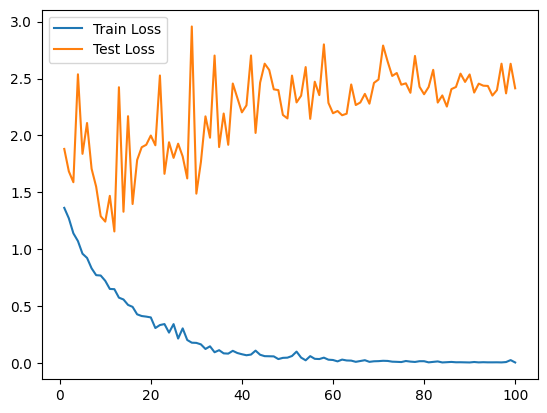

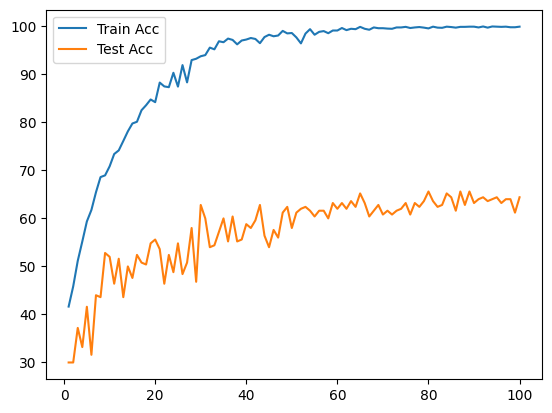

In [5]:
import pandas as pd

df = pd.read_csv("/kaggle/working/history.csv")

history = {
    "train_loss": df["train_loss"].tolist(),
    "test_loss": df["test_loss"].tolist(),
    "train_acc": df["train_acc"].tolist(),
    "test_acc": df["test_acc"].tolist(),
}
# def plot_history(csv_path):
#     import pandas as pd
#     df = pd.read_csv(csv_path)

#     epochs = range(1, len(df) + 1)

#     plt.figure()
#     plt.plot(epochs, df["train_loss"], label="Train Loss")
#     plt.plot(epochs, df["test_loss"], label="Test Loss")
#     plt.legend()
#     plt.show()
import matplotlib.pyplot as plt

def plot_history(history):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure()
    plt.plot(epochs, history["train_loss"], label="Train Loss")
    plt.plot(epochs, history["test_loss"], label="Test Loss")
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(epochs, history["train_acc"], label="Train Acc")
    plt.plot(epochs, history["test_acc"], label="Test Acc")
    plt.legend()
    plt.show()
plot_history(history)

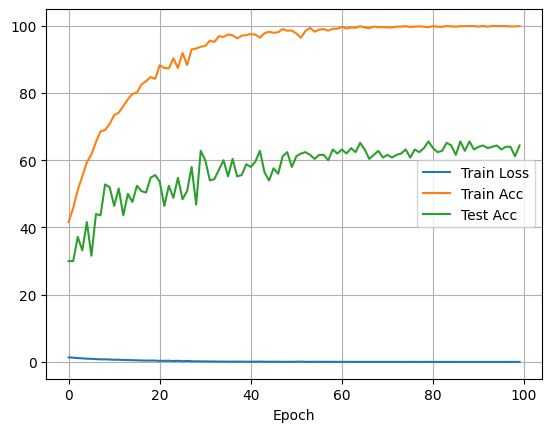

In [6]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["train_acc"], label="Train Acc")
plt.plot(history["test_acc"], label="Test Acc")

plt.xlabel("Epoch")
plt.legend()
plt.grid()

plt.show()